# LDA + Regression

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import numpy as np

In [10]:
iris = load_iris()
X, y = iris.data, iris.target
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X,y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_lda, y, random_state=123, train_size=0.8)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 2)
(30, 2)
(120,)
(30,)


In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
y_pred_lda = lda.predict(X)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [6]:
for i in range(3):
  print(f"Class {i}: w1 = {model.coef_[i][0]:.4f}, w2 = {model.coef_[i][1]:.4f}, intercept = {model.intercept_[i]:.4f}")

Class 0: w1 = 1.6219, w2 = -0.0764, intercept = 0.7403
Class 1: w1 = 0.3909, w2 = 0.1794, intercept = 4.3598
Class 2: w1 = -2.0128, w2 = -0.1030, intercept = -5.1001


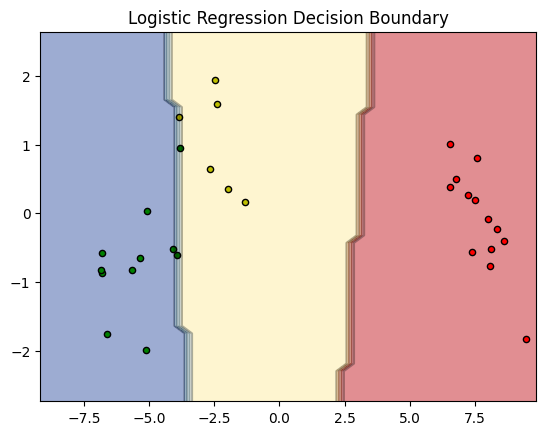

In [43]:
from matplotlib import pyplot as plt
ax = plt.gca()
# Plot x, y with the new feature from LDA
x_min = X_lda.T[0].min()
x_max = X_lda.T[0].max()
y_min = X_lda.T[1].min()
y_max = X_lda.T[1].max()
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))
z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
z_class = np.argmax(z, axis=1).reshape(xx.shape)

c = ax.contourf(xx, yy, z_class, cmap='RdYlBu', alpha=0.5)
c1 = ax.contour(xx, yy, z_class, colors='black', alpha=0.3)

plt.scatter(X_test[y_test==0,0], X_test[y_test==0,1], c='r', edgecolor='k', s=20)
plt.scatter(X_test[y_test==1,0], X_test[y_test==1,1], c='y', edgecolor='k', s=20)
plt.scatter(X_test[y_test==2,0], X_test[y_test==2,1], c='g', edgecolor='k', s=20)
ax.set_title('Logistic Regression Decision Boundary')
plt.show()

# LDA only


In [58]:
X_train2, X_test2, y_train2, y_test2 =  train_test_split(X, y, random_state=123, train_size=0.8)
lda2 = LDA(n_components=2)
lda2.fit_transform(X_train2, y_train2)
y_lda_pred = lda2.predict(X_test2)

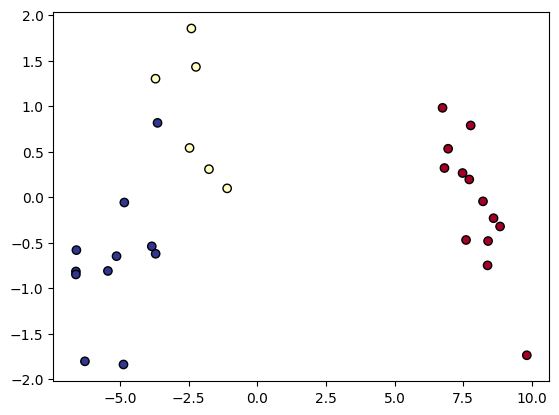

In [59]:
import numpy as np
from matplotlib import pyplot as plt
plt.scatter(X_test2_lda[:,0], X_test2_lda[:,1], c=y_test2, cmap='RdYlBu', edgecolor='k')
plt.show()

## Compare LDA only and logistic regression

In [61]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def eval(test, pred):
  acc = accuracy_score(test, pred)
  rec = recall_score(test, pred, average='macro')
  prec = precision_score(test, pred, average='macro')
  f1 = f1_score(test, pred, average='macro')
  return(acc,rec,prec,f1)

acc_lda, rec_lda, prec_lda, f1_lda = eval(y_test, y_lda_pred)
print("=" * 50)
print("LDA Only:")
print(f"  Accuracy:  {acc_lda:.4f}")
print(f"  Recall:    {rec_lda:.4f}")
print(f"  Precision: {prec_lda:.4f}")
print(f"  F1 Score:  {f1_lda:.4f}")

acc_lr, rec_lr, prec_lr, f1_lr = eval(y_test, y_pred)
print("\nLDA + Logistic Regression:")
print(f"  Accuracy:  {acc_lr:.4f}")
print(f"  Recall:    {rec_lr:.4f}")
print(f"  Precision: {prec_lr:.4f}")
print(f"  F1 Score:  {f1_lr:.4f}")
print("=" * 50)

LDA Only:
  Accuracy:  0.9667
  Recall:    0.9697
  Precision: 0.9524
  F1 Score:  0.9585

LDA + Logistic Regression:
  Accuracy:  0.9667
  Recall:    0.9697
  Precision: 0.9524
  F1 Score:  0.9585


The result are identical between using lda.predict2(X_test2) and model.predict(X_test)

- Logistic regression
  - classification model
  - supervised
  - use functions to transform linear regression into logistic function

- lda
  - dimension reduction method
  - supervised
  - preserved class find discriminant axis

- pca
  - dimension reduction method
  - unsupervised
  - don't preserved class and base on finding principle components

# PCA

In [ ]:
# while LDA does not require standardization (use variance to compute)
# PCA need to standardized data first
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
pca = PCA(2)
X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)
print(X_pca)

In [86]:
model_pca = LogisticRegression()
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
